In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Standard imports
import numpy as np
import xarray as xr
import tqdm as tqdm

In [3]:
# Import OpenSense modules as submodules
import sys
import os

sys.path.append(os.path.abspath("./pycomlink/"))
sys.path.append(os.path.abspath("./poligrain/src/"))
sys.path.append(os.path.abspath("./mergeplg/src/"))

import pycomlink as pycml 
import poligrain as plg
import mergeplg 

In [4]:
# For variogram estimation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

from scipy.ndimage import label
from scipy.spatial.distance import pdist
from scipy.optimize import curve_fit

In [5]:
# Define function to estimate variogram from rainfall event
def get_event_variogram(da_event, bin_edges, min_obs, plot_variogram=False):
    """
    da_event: xarray data for computing variogram
    bin_edges: array of distance bins [m] (e.g., np.linspace(0, 30000, 1500))
    min_obs: minimum observations needed to perform variogram estimation
    plot_variogram: whether to plot the variogram
    """
    all_distances = []
    all_sq_diffs = []
    
    # 1. Collect pairs from all time steps in the event
    n_obs = 0
    for t in da_event.time:
        # Extract data for this timestamp and drop nan
        data_t = da_event.sel(time=t).dropna(dim='cml_id')
        
        # We need at least 2 points to make a pair
        if len(data_t.cml_id) < 2:
            continue

        n_obs += data_t.cml_id.size

        # Get coordinates of data
        coords = np.column_stack([data_t.x, data_t.y])
        values = data_t.values
        
        # Calculate distances and 0.5 * (zi - zj)^2
        dist = pdist(coords, metric='euclidean')

        # Calculate squared distance (variance)
        sq_diff = 0.5 * pdist(values[:, None], 'sqeuclidean')
        
        all_distances.append(dist)
        all_sq_diffs.append(sq_diff)

    # If not enough observations
    if n_obs < min_obs:
        return None
        
    # Flatten into two long arrays of all pairs in the event
    dist_pool = np.concatenate(all_distances)
    diff_pool = np.concatenate(all_sq_diffs)
    
    # 2. Binning 
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    gamma_obs = []
    count = []

    # Also drop largest outliers
    #diff_upper = np.nanquantile(dist_pool, q = 0.95)
    
    for i in range(len(bin_edges)-1):
        mask = (dist_pool > bin_edges[i]) & (dist_pool <= bin_edges[i+1]) # & (diff_pool <= diff_upper) 
        if np.any(mask):
            gamma_obs.append(np.mean(diff_pool[mask]))
            count.append(diff_pool[mask].size)
        else:
            gamma_obs.append(np.nan)
            count.append(0)

    count = np.array(count)
    gamma_obs = np.array(gamma_obs)

    # 3. Define valid observation bins and get variance
    valid = ~np.isnan(gamma_obs) & (count != 0) 

    # Locate where most observations are
    dist_lower = np.nanquantile(dist_pool, q = 0.05)
    dist_upper = np.nanquantile(dist_pool, q = 0.95)
    ind_lower = np.where(dist_lower < bin_centers[valid])[0][0]

    if (dist_upper > bin_centers[valid]).all():
        ind_upper = bin_centers[valid].size
    else:
        ind_upper = np.where(dist_upper < bin_centers[valid])[0][0]

    total_variance = np.nanmean(gamma_obs[valid][ind_lower:ind_upper])
    gamma_obs_norm = gamma_obs/total_variance

    # If no variance 
    if total_variance == 0: 
        return None
        
    # 4. Define variogram and bounds
    def spherical_model(h, nugget, p_sill, range_a):
        # Use same definitions as pykrige:
        # https://geostat-framework.readthedocs.io/projects/pykrige/en/stable/variogram_models.html
        return np.where(h <= range_a, 
                        p_sill * (1.5 * (h/range_a) - 0.5 * (h/range_a)**3) + nugget, 
                        p_sill + nugget)
        
    # Estimate partial sill from normalized variance
    def f(h, n, r):
        return spherical_model(h, n, 1 - n, r)
        
    # Initial guess: [min(gamma), max_dist/2]
    p0 = [0, np.max(bin_centers[valid][ind_lower:ind_upper])/2]

    # Parameter bounds
    bound_l_nugget = 0
    bound_l_range = bin_centers[valid][ind_lower]
    bound_u_nugget = np.min([np.nanmean(gamma_obs_norm[valid][:ind_lower+1]), 1])
    bound_u_range = np.max(bin_edges)*2

    if bound_u_nugget == 0:
        bound_u_nugget = 0.01 # For numerics
    
    bounds = [[bound_l_nugget, bound_l_range], [bound_u_nugget, bound_u_range]]
    
    # 5. Optimize and return parameters
    popt, _ = curve_fit(
        f, 
        bin_centers[valid][:ind_upper], 
        gamma_obs_norm[valid][:ind_upper], 
        p0=p0, 
        bounds=bounds,
    )

    nugget = popt[0]
    p_sill = 1 - nugget
    range_a = popt[1]

    if plot_variogram:
        fig, ax = plt.subplots(1, 1)
        ax.plot(bin_centers[valid], spherical_model(bin_centers[valid], nugget, p_sill, range_a), label='plot variogram')
        ax.plot(bin_centers[valid][:ind_upper], gamma_obs_norm[valid][:ind_upper], label='data used')
        ax.plot(bin_centers[valid][ind_upper:], gamma_obs_norm[valid][ind_upper:], label='data left out')
        plt.legend()
        plt.show()
    
    return n_obs, [nugget, p_sill, range_a]


In [6]:
def estimate_several_variograms(ds_cmls, target_variable, labels, num_features):
    # Variogram difference radar-cml
    bin_edges = np.arange(0, 60000, 1000) # Varigroam bin size
    min_obs = 100 # Minimum observations required to perform variogram estimation, else expand search
    
    variograms = []
    # Estimate variogram for rainfall events
    for i in tqdm.tqdm(range(1, num_features + 1)):
        # neighbouring events to include
        n_neighbors = 0 
    
        # Event for variogram estimation
        target_labels = np.arange(max(1, i - n_neighbors), min(num_features, i + n_neighbors) + 1)
        combined_event_time = mask.time.where(labels.isin(target_labels), drop=True)
    
        # Expand neighbourhood until we have enough data
        expand = True
        while expand:
            # Get start-end time
            time_start = combined_event_time.time.values[0]
            time_end = combined_event_time.time.values[-1]
            time_mid = combined_event_time.time.values[int(combined_event_time.time.size/2)]
            
            # Estimate variogram 
            out = get_event_variogram( 
                ds_cmls[target_variable].sel(time = slice(time_start, time_end)), # 
                bin_edges, 
                min_obs,
                plot_variogram = False,
            )
    
            # If variogram estimation was successful, stop expanding
            if out is not None:
                expand = False 
                n_obs = out[0]
                variograms.append([time_mid, out[1][0], out[1][1], out[1][2]])
                
            else:
                # Timesteps included in event
                n_time = combined_event_time.time.size
    
                # Expand neighborhood
                n_neighbors +=1
                target_labels = np.arange(max(1, i - n_neighbors), min(num_features, i + n_neighbors) + 1)
                combined_event_time = mask.time.where(labels.isin(target_labels), drop=True)
        
                # Break loop if exand did not result in more timesteps
                if n_time >= combined_event_time.time.size:
                    expand = False
                    print('Warning: Not enough rainfall obs in time series, using standard instead')
                    variograms = [[time_mid, 0.2, 0.8, 30000]]
    
    variograms = pd.DataFrame(variograms, columns=['time', 'nugget', 'psill', 'range']).set_index('time')
    
    return variograms

# READ DATA TO LIST

In [7]:
# Read openmrg and openrainer datasets
rad_openmrg = "data/andersson_2022_OpenMRG/radar/openmrg_rad.nc"
cmls_openmrg = "data/processed_cml_OpenMRG.nc"
gauges_openmrg = "data/andersson_2022_OpenMRG/gauges/openmrg_gauges.nc"

rad_openrainer = "data/covi_2024_OpenRainER/openrainer_radar.nc"
cmls_openrainer = "data/processed_cml_OpenRainER.nc"
gauges_openrainer = "data/covi_2024_OpenRainER/AWS_rainfall.nc"

iterate = [
    [xr.open_dataset(rad_openmrg), xr.open_dataset(cmls_openmrg), xr.open_dataset(gauges_openmrg)], 
    [xr.open_dataset(rad_openrainer), xr.open_dataset(cmls_openrainer), xr.open_dataset(gauges_openrainer)],
]

# For through the two datasets
for i in range(2):
    ds_rad = iterate[i][0]
    ds_cmls = iterate[i][1]
    ds_gauges = iterate[i][2]
    
    # Get CML midpoints
    ds_cmls.coords['lon'] = (ds_cmls.site_0_lon + ds_cmls.site_1_lon)/2
    ds_cmls.coords['lat'] = (ds_cmls.site_0_lat + ds_cmls.site_1_lat)/2
    
    # Get radar along CML
    da_intersect_weights = plg.spatial.calc_sparse_intersect_weights_for_several_cmls(
        x1_line=ds_cmls.site_0_lon.values,
        y1_line=ds_cmls.site_0_lat.values,
        x2_line=ds_cmls.site_1_lon.values,
        y2_line=ds_cmls.site_1_lat.values,
        cml_id=ds_cmls.cml_id.values,
        x_grid=ds_rad.lon.values,
        y_grid=ds_rad.lat.values,
        grid_point_location='center',
    )
    ds_cmls['radar_along_cml'] = plg.spatial.get_grid_time_series_at_intersections(
        grid_data=ds_rad.rainfall_amount,
        intersect_weights=da_intersect_weights,
    )
    
    # Radar at CML midpoint
    get_grid_at_points = plg.spatial.GridAtPoints(
        da_gridded_data=ds_rad,
        da_point_data=ds_cmls.rename({'cml_id': 'id'}),
        nnear=1,
        stat="best",
    )
    ds_cmls['radar_at_midpoint'] = get_grid_at_points(
        da_gridded_data=ds_rad.rainfall_amount,
        da_point_data=ds_cmls.R_acc.rename({'cml_id': 'id'}),
    ).rename({'id': 'cml_id'})
    
    # Difference and ratio between CML and radar, cases where radar is zero are set to nan and ignored in the variogram estimation
    ds_cmls['rainfall_difference'] = xr.where(ds_cmls.radar_along_cml > 0, ds_cmls.R_acc - ds_cmls.radar_along_cml, np.nan)
    ds_cmls['rainfall_ratio'] = xr.where(ds_cmls.radar_along_cml > 0, ds_cmls.R_acc/ds_cmls.radar_along_cml, np.nan)
    ds_cmls['rainfall_radarmidpoint'] = xr.where(ds_cmls.radar_along_cml > 0, ds_cmls.radar_at_midpoint, np.nan)
    ds_cmls['rainfall_obs'] = xr.where(ds_cmls.radar_along_cml > 0, ds_cmls.R_acc, np.nan)
    
    # Radar at raingauges
    get_grid_at_points = plg.spatial.GridAtPoints(
        da_gridded_data=ds_rad,
        da_point_data=ds_gauges,
        nnear=1,
        stat="best",
    )
    
    ds_gauges['radar_at_gauge'] = get_grid_at_points(
        da_gridded_data=ds_rad.rainfall_amount,
        da_point_data=ds_gauges.rainfall_amount,
    )
    
    # Difference and ratio between raingauge and radar, could be tricky to use as gauges might not estimate rainfall when CML does.. 
    ds_gauges['rainfall_difference'] = xr.where(ds_gauges.radar_at_gauge > 0, ds_gauges.rainfall_amount - ds_gauges.radar_at_gauge, np.nan)
    ds_gauges['rainfall_ratio'] = xr.where(ds_gauges.radar_at_gauge > 0, ds_gauges.rainfall_amount/ds_gauges.radar_at_gauge, np.nan)
    ds_gauges['rainfall_radarmidpoint'] = xr.where(ds_gauges.radar_at_gauge > 0, ds_gauges.radar_at_gauge, np.nan)
    ds_gauges['rainfall_obs'] = xr.where(ds_gauges.radar_at_gauge > 0, ds_gauges.rainfall_amount, np.nan)
    

# ESTIMATE VARIOGRAMS

In [8]:
# estimate varigorams
variograms = []
for i in range(2):
    ds_cmls = iterate[i][1]
    ds_gauges = iterate[i][2]

    # Find nearby rainfall (closer than 6 hours) to estimate variogram
    mask = (ds_cmls.radar_along_cml > 0.01).any(dim='cml_id').rolling(time=12, center=True).sum() > 0
    mask = mask.fillna(0).astype(int) # Ensure no NaNs and int type for labeling
    labels_raw, num_features = label(mask)
    labels = xr.DataArray(labels_raw, coords=mask.coords, dims=mask.dims)

    variograms.append([])
    variograms[-1].append(estimate_several_variograms(ds_cmls, 'rainfall_difference', labels, num_features))
    variograms[-1].append(estimate_several_variograms(ds_cmls, 'rainfall_ratio', labels, num_features))
    variograms[-1].append(estimate_several_variograms(ds_cmls, 'rainfall_obs', labels, num_features))
    variograms[-1].append(estimate_several_variograms(ds_cmls, 'rainfall_radarmidpoint', labels, num_features))

    variograms[-1].append(estimate_several_variograms(ds_gauges.rename({'id':'cml_id'}), 'rainfall_difference', labels, num_features))
    variograms[-1].append(estimate_several_variograms(ds_gauges.rename({'id':'cml_id'}), 'rainfall_ratio', labels, num_features))
    variograms[-1].append(estimate_several_variograms(ds_gauges.rename({'id':'cml_id'}), 'rainfall_obs', labels, num_features))
    variograms[-1].append(estimate_several_variograms(ds_gauges.rename({'id':'cml_id'}), 'rainfall_radarmidpoint', labels, num_features))




 90%|███████████████████████████████████████████████████████████████████████████████████████████████████████            | 26/29 [00:11<00:01,  2.90it/s]/tmp/ipykernel_21599/4072047553.py:79: RuntimeWarning: invalid value encountered in divide
  gamma_obs_norm = gamma_obs/total_variance
 90%|███████████████████████████████████████████████████████████████████████████████████████████████████████            | 26/29 [00:11<00:00,  3.19it/s]/tmp/ipykernel_21599/4072047553.py:79: RuntimeWarning: invalid value encountered in divide
  gamma_obs_norm = gamma_obs/total_variance
 17%|████████████████████                                                                                                | 5/29 [00:01<00:07,  3.16it/s]/tmp/ipykernel_21599/4072047553.py:79: RuntimeWarning: invalid value encountered in divide
  gamma_obs_norm = gamma_obs/total_variance
 17%|████████████████████                                                                                                | 5/29 [00:02<00:0

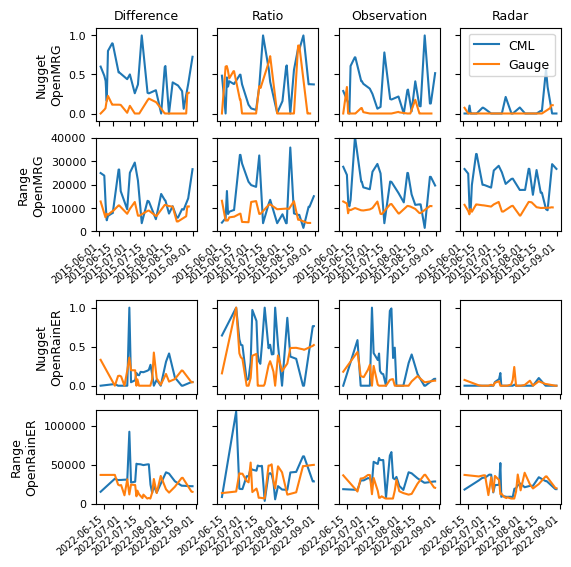

In [11]:
# Use 5 rows (to insert a gap) and 4 columns
fig = plt.figure(figsize=(6, 7))
labelsize = 7
labelrotation = 40
gs = gridspec.GridSpec(
    5, 4,
    height_ratios=[1, 1, 0.38, 1, 1]  # 0.2 row is the vertical gap
)

ax = np.empty((4, 4), dtype=object)

# First block (rows 0, 1)
for method_j in range(4):
    ax[0, method_j] = fig.add_subplot(gs[0, method_j])
    ax[1, method_j] = fig.add_subplot(gs[1, method_j])

    # CML
    variograms[0][method_j]['nugget'].plot(ax=ax[0, method_j], label='obs', color='C0')
    variograms[0][method_j]['range'].plot(ax=ax[1, method_j], label='obs', color='C0')

    # CML nugget mean
    step_means = variograms[0][method_j]['nugget'].resample('14D').mean()
    end_row = pd.DataFrame([float(variograms[0][method_j]['nugget'].iloc[-1])], index=[variograms[0][method_j]['nugget'].index[-1]])
    step_means = pd.concat([step_means, end_row]).sort_index()
    #ax[0, method_j].step(step_means.index, step_means.values, where='post', color='C0', linestyle='dotted', label='14-day mean')

    # CML range mean
    step_means = variograms[0][method_j]['range'].resample('14D').mean()
    end_row = pd.DataFrame([float(variograms[0][method_j]['range'].iloc[-1])], index=[variograms[0][method_j]['range'].index[-1]])
    step_means = pd.concat([step_means, end_row]).sort_index()
    #ax[1, method_j].step(step_means.index, step_means.values, where='post', color='C0', linestyle='dotted', label='14-day mean')



    shift = 4
    variograms[0][method_j + shift]['nugget'].plot(ax=ax[0, method_j], label='obs', color='C1')
    variograms[0][method_j + shift]['range'].plot(ax=ax[1, method_j], label='obs', color='C1')

    # Raingauge nugget mean
    step_means = variograms[0][method_j + shift]['nugget'].resample('14D').mean()
    end_row = pd.DataFrame([float(variograms[0][method_j + shift]['nugget'].iloc[-1])], index=[variograms[0][method_j + shift]['nugget'].index[-1]])
    step_means = pd.concat([step_means, end_row]).sort_index()
    #ax[0, method_j].step(step_means.index, step_means.values, where='post', color='C1', linestyle='dotted', label='14-day mean')

    # Raingauge range mean
    step_means = variograms[0][method_j + shift]['range'].resample('14D').mean()
    end_row = pd.DataFrame([float(variograms[0][method_j + shift]['range'].iloc[-1])], index=[variograms[0][method_j + shift]['range'].index[-1]])
    step_means = pd.concat([step_means, end_row]).sort_index()
    #ax[1, method_j].step(step_means.index, step_means.values, where='post', color='C1', linestyle='dotted', label='14-day mean')

    
    ax[0, method_j].set_ylim(-0.1, 1.1)
    ax[1, method_j].set_ylim(0, 40000)
    ax[0, method_j].tick_params(axis='x', labelsize=labelsize, labelrotation=labelrotation)
    ax[0, method_j].tick_params(axis='y', labelsize=8)
    
    ax[1, method_j].tick_params(axis='x', labelsize=labelsize, labelrotation=labelrotation)
    ax[1, method_j].tick_params(axis='y', labelsize=8)

    ax[0, method_j].set_xlabel('')
    ax[1, method_j].set_xlabel('')
    ax[0, method_j].tick_params(axis='x', labelbottom=False)
    
    if method_j > 0:
        ax[0, method_j].tick_params(axis='y', labelleft=False)
        ax[1, method_j].tick_params(axis='y', labelleft=False)
    else:
        ax[0, method_j].set_ylabel('Nugget\nOpenMRG', fontsize=9)
        ax[1, method_j].set_ylabel('Range\nOpenMRG', fontsize=9)





# First block (rows 0, 1)
for method_j in range(4):
    ax[2, method_j] = fig.add_subplot(gs[3, method_j])
    ax[3, method_j] = fig.add_subplot(gs[4, method_j])

    # CML
    variograms[1][method_j]['nugget'].plot(ax=ax[2, method_j], label='obs', color='C0')
    variograms[1][method_j]['range'].plot(ax=ax[3, method_j], label='obs', color='C0')

    # CML nugget mean
    step_means = variograms[1][method_j]['nugget'].resample('14D').mean()
    end_row = pd.DataFrame([float(variograms[0][method_j]['nugget'].iloc[-1])], index=[variograms[1][method_j]['nugget'].index[-1]])
    step_means = pd.concat([step_means, end_row]).sort_index()
    #ax[2, method_j].step(step_means.index, step_means.values, where='post', color='C0', linestyle='dotted', label='14-day mean')

    # CML range mean
    step_means = variograms[1][method_j]['range'].resample('14D').mean()
    end_row = pd.DataFrame([float(variograms[0][method_j]['range'].iloc[-1])], index=[variograms[1][method_j]['range'].index[-1]])
    step_means = pd.concat([step_means, end_row]).sort_index()
    #ax[3, method_j].step(step_means.index, step_means.values, where='post', color='C0', linestyle='dotted', label='14-day mean')

    # Raingauge
    shift = 4
    variograms[1][method_j + shift]['nugget'].plot(ax=ax[2, method_j], label='obs', color='C1')
    variograms[1][method_j + shift]['range'].plot(ax=ax[3, method_j], label='obs', color='C1')

    # Raingauge nugget mean
    step_means = variograms[1][method_j + shift]['nugget'].resample('14D').mean()
    end_row = pd.DataFrame([float(variograms[1][method_j + shift]['nugget'].iloc[-1])], index=[variograms[1][method_j + shift]['nugget'].index[-1]])
    step_means = pd.concat([step_means, end_row]).sort_index()
    #ax[2, method_j].step(step_means.index, step_means.values, where='post', color='C1', linestyle='dotted', label='14-day mean')

    # Raingauge range mean
    step_means = variograms[1][method_j + shift]['range'].resample('14D').mean()
    end_row = pd.DataFrame([float(variograms[1][method_j + shift]['range'].iloc[-1])], index=[variograms[1][method_j + shift]['range'].index[-1]])
    step_means = pd.concat([step_means, end_row]).sort_index()
    #ax[3, method_j].step(step_means.index, step_means.values, where='post', color='C1', linestyle='--', label='14-day mean')

    
    ax[2, method_j].set_ylim(-0.1, 1.1)
    ax[3, method_j].set_ylim(0, 120000)
    ax[2, method_j].tick_params(axis='x', labelsize=labelsize, labelrotation=labelrotation)
    ax[2, method_j].tick_params(axis='y', labelsize=8)

    ax[3, method_j].tick_params(axis='x', labelsize=labelsize, labelrotation=labelrotation)
    ax[3, method_j].tick_params(axis='y', labelsize=8)

    ax[2, method_j].set_xlabel('')
    ax[3, method_j].set_xlabel('')
    ax[2, method_j].tick_params(axis='x', labelbottom=False)
    
    if method_j > 0:
        ax[2, method_j].tick_params(axis='y', labelleft=False)
        ax[3, method_j].tick_params(axis='y', labelleft=False)
    else:
        ax[2, method_j].set_ylabel('Nugget\nOpenRainER', fontsize=9)
        ax[3, method_j].set_ylabel('Range\nOpenRainER', fontsize=9)
        
ax[0, 0].set_title('Difference', fontsize=9)
ax[0, 1].set_title('Ratio', fontsize=9)
ax[0, 2].set_title('Observation', fontsize=9)
ax[0, 3].set_title('Radar', fontsize=9)


import matplotlib.lines as mlines
cml_line = mlines.Line2D([], [], color='C0', label='CML')
gauge_line = mlines.Line2D([], [], color='C1', label='Gauge')
ax[0, 3].legend(handles=[cml_line, gauge_line], loc='upper right', fontsize=9, frameon=True)

fig.savefig('./figures/variogram_analysis.png', dpi=600, bbox_inches='tight')
